<a href="https://colab.research.google.com/github/phuonglinhday1048-hue/Phantichdl-hs/blob/main/Lab5_Dang_Ngoc_Phuong_Linh_2474802010559.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                             download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                            download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
           'Sandal','Shirt','Sneaker','Bag','Ankle boot']

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 273kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.06MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.34MB/s]


In [2]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()

In [3]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net.to(device)

for epoch in range(5):
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader)}")

print("Huấn luyện xong!")

Epoch 1, Loss: 0.5187907270404067
Epoch 2, Loss: 0.37006198216094643
Epoch 3, Loss: 0.3306057481115052
Epoch 4, Loss: 0.3056419510751772
Epoch 5, Loss: 0.2876426860976067
Huấn luyện xong!


In [4]:
correct = 0
total = 0
net.eval()
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Độ chính xác trên tập test: {100 * correct / total:.2f}%")

Độ chính xác trên tập test: 87.33%


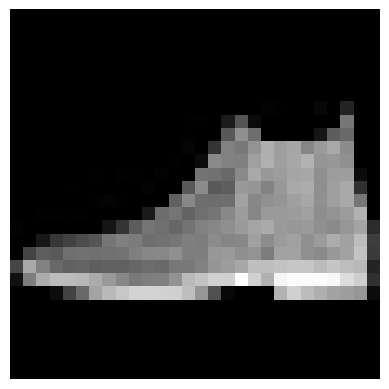

Thực tế: Ankle boot | Dự đoán: Ankle boot


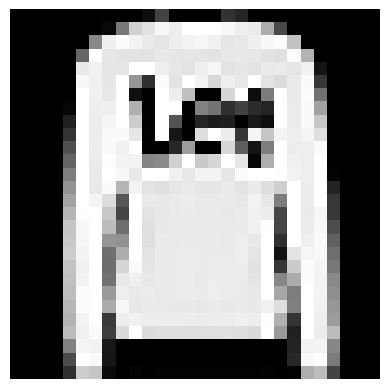

Thực tế: Pullover | Dự đoán: Pullover


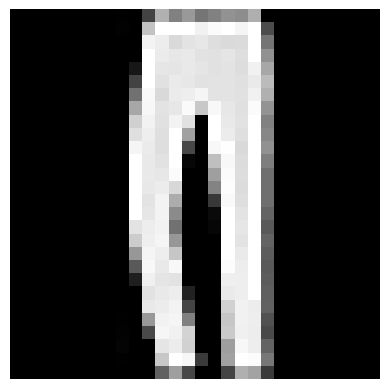

Thực tế: Trouser | Dự đoán: Trouser


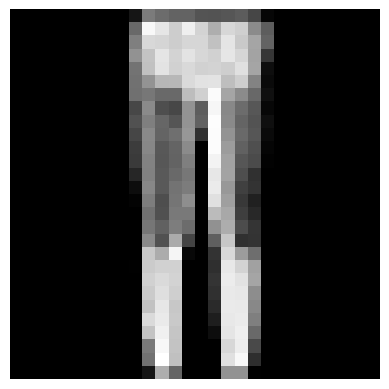

Thực tế: Trouser | Dự đoán: Trouser


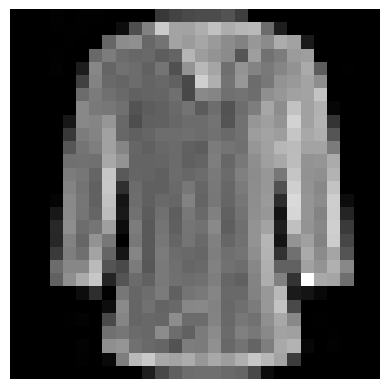

Thực tế: Shirt | Dự đoán: Shirt


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Hàm hiển thị ảnh
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.axis('off')
    plt.show()

# Lấy một batch từ test_loader
dataiter = iter(testloader)
images, labels = next(dataiter)

# Dự đoán
images, labels = images.to(device), labels.to(device)
outputs = net(images)
_, predicted = torch.max(outputs, 1)

# Hiển thị 5 ảnh đầu tiên với nhãn thực tế và nhãn dự đoán
for i in range(5):
    imshow(images[i].cpu())
    print(f"Thực tế: {classes[labels[i]]} | Dự đoán: {classes[predicted[i]]}")

In [7]:
torch.save(net.state_dict(), "fashion_mnist_model.pth")